# Results Figures

Clean figures for the paper, organized by research question.
Each section states the question, produces the figure(s), and leaves
space for interpretation after inspection.

**Focal layer:** L20 (index 19) — strongest harmfulness signal across conditions.
Change `FOCAL_LAYER` below to explore other layers.

In [1]:
import json as _json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, silhouette_score
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

repo_root = Path('..').resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

MODEL     = 'llama'   # model subdirectory under data/

REPR_ROOT = repo_root / 'data' / MODEL / 'representations'
CONV_ROOT = repo_root / 'data' / MODEL / 'conversations'
FIG_DIR   = repo_root / 'figures'

FRAMEWORKS      = ['crescendo', 'actorattack', 'xteaming']
FW_LABELS       = {'crescendo': 'Crescendo', 'actorattack': 'ActorAttack', 'xteaming': 'X-Teaming'}
FW_COLORS       = {'crescendo': '#1f77b4', 'actorattack': '#d62728', 'xteaming': '#2ca02c'}
SPLITS          = ['harmful', 'benign']
FOCAL_LAYER     = 19   # 0-indexed; L20
FOCAL_LABEL     = 'L20'
ALL_LAYERS      = [3, 7, 11, 15, 19, 23, 27, 31]
ALL_LAYER_LABELS = ['L4', 'L8', 'L12', 'L16', 'L20', 'L24', 'L28', 'L32']
TRAIN_MAX       = 16
MAX_K           = 10
RNG             = 42

plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.size': 9, 'axes.titlesize': 10, 'axes.labelsize': 9,
    'legend.fontsize': 7, 'xtick.labelsize': 8, 'ytick.labelsize': 8,
})
print('Config ready.')

Config ready.


/Users/lisahusieva/Desktop/multi-turn-rep-eng/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_repr(folder):
    meta   = pd.read_parquet(folder / 'metadata.parquet')
    h_inst = np.load(folder / 'h_inst.npy', mmap_mode='r')
    h_post = np.load(folder / 'h_post_inst.npy', mmap_mode='r')
    return {'meta': meta, 'h_inst': h_inst, 'h_post': h_post}

def add_split(meta):
    meta['data_split'] = np.where(meta['attempt'] <= TRAIN_MAX, 'train', 'test')

traj, nc, st = {}, {}, {}
for fw in FRAMEWORKS:
    for split in SPLITS:
        for tag, store, sub in [('traj', traj, 'trajectories'), ('nc', nc, 'nocontext')]:
            f = REPR_ROOT / sub / f'{fw}_{split}'
            if f.exists():
                store[(fw, split)] = load_repr(f)
                add_split(store[(fw, split)]['meta'])
for split in SPLITS:
    f = REPR_ROOT / 'single_turn' / split
    if f.exists(): st[split] = load_repr(f)

# Compressed
comp = {}
for fw in FRAMEWORKS:
    for split in SPLITS:
        f = REPR_ROOT / 'compressed' / f'{fw}_{split}'
        if f.exists():
            comp[(fw, split)] = load_repr(f)
            add_split(comp[(fw, split)]['meta'])

avail_fw = sorted({fw for fw, _ in traj.keys()})
has_nc = bool(nc)
has_comp = bool(comp)
n_fw = len(avail_fw)

# Per-turn behavioral labels (Crescendo)
def load_turn_labels(conv_dir):
    records = []
    for fpath in sorted(conv_dir.glob('*.json')):
        c = _json.load(open(fpath))
        by_idx = {}
        for t in c.get('turns', []):
            by_idx.setdefault(t['turn_idx'], {})[t['role']] = t
        k = 0
        for ti in sorted(by_idx):
            p = by_idx[ti]
            u, a = p.get('user'), p.get('assistant')
            if not u or not a: continue
            if u.get('rolled_back', False) or a.get('rolled_back', False): continue
            k += 1
            records.append({'pair_id': c['objective_pair_id'], 'attempt': c.get('attempt',1),
                            'turn_k': k, 'is_refusal': bool(a.get('is_refusal', False)),
                            'judge_success': bool(a.get('judge_success', False))})
    return pd.DataFrame(records)

turn_labels = {}
for fw in avail_fw:
    d = CONV_ROOT / f'{fw}_harmful'
    if d.exists(): turn_labels[fw] = load_turn_labels(d)

print(f'Frameworks: {avail_fw}  NC: {has_nc}  Comp: {has_comp}')

Frameworks: ['actorattack', 'crescendo', 'xteaming']  NC: True  Comp: True


In [3]:
def final_turn_idx(data):
    m = data['meta']
    if 'turn_k' in m.columns:
        return m.groupby('conversation_id')['turn_k'].idxmax().values
    return np.arange(len(m))

def paired_direction(h_a, m_a, h_b, m_b, layer):
    pairs = sorted(set(m_a['pair_id']) & set(m_b['pair_id']))
    diffs = []
    for p in pairs:
        ia = m_a.index[m_a['pair_id'] == p].tolist()
        ib = m_b.index[m_b['pair_id'] == p].tolist()
        if not ia or not ib: continue
        diffs.append(h_a[ia, layer, :].astype(np.float32).mean(0) -
                     h_b[ib, layer, :].astype(np.float32).mean(0))
    if not diffs: return None
    d = np.stack(diffs).mean(0)
    return d / (np.linalg.norm(d) + 1e-12)

def direction_at_k(data_dict, fw, h_key, layer, k):
    dh, db = data_dict.get((fw,'harmful')), data_dict.get((fw,'benign'))
    if dh is None or db is None: return None
    mh = (dh['meta']['turn_k']==k) & (dh['meta']['data_split']=='train')
    mb = (db['meta']['turn_k']==k) & (db['meta']['data_split']=='train')
    if mh.sum()<10 or mb.sum()<10: return None
    return paired_direction(dh[h_key][mh.values], dh['meta'][mh].reset_index(drop=True),
                            db[h_key][mb.values], db['meta'][mb].reset_index(drop=True), layer)

def direction_overall(data_dict, fw, h_key, layer):
    dh, db = data_dict.get((fw,'harmful')), data_dict.get((fw,'benign'))
    if dh is None or db is None: return None
    mh = dh['meta']['data_split']=='train' if 'data_split' in dh['meta'].columns else pd.Series(True, index=dh['meta'].index)
    mb = db['meta']['data_split']=='train' if 'data_split' in db['meta'].columns else pd.Series(True, index=db['meta'].index)
    return paired_direction(dh[h_key][mh.values], dh['meta'][mh].reset_index(drop=True),
                            db[h_key][mb.values], db['meta'][mb].reset_index(drop=True), layer)

def cosine(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12)

print('Direction helpers ready.')

Direction helpers ready.


In [4]:
L = FOCAL_LAYER

# Single-turn baseline
m_st_h = st['harmful']['meta'].sort_values('pair_id')
m_st_b = st['benign']['meta'].sort_values('pair_id')

def compute_v_st(h_key, layer):
    d = (st['harmful'][h_key][m_st_h.index, layer, :].astype(np.float32) -
         st['benign'][h_key][m_st_b.index, layer, :].astype(np.float32))
    d_mean = d.mean(0)
    return d_mean / (np.linalg.norm(d_mean) + 1e-12)

v_st = {li: compute_v_st('h_inst', li) for li in ALL_LAYERS}
v_st_post = {li: compute_v_st('h_post', li) for li in ALL_LAYERS}

# Per-turn directions (full-context and no-context)
v_full, v_nc_dir, v_comp_dir = {}, {}, {}
n_at_k = {}  # sample counts

for fw in tqdm(avail_fw, desc='Directions'):
    for k in range(1, MAX_K+1):
        v_full[(fw,k)] = direction_at_k(traj, fw, 'h_inst', L, k)
        v_full[(fw,'post',k)] = direction_at_k(traj, fw, 'h_post', L, k)
        if has_nc:
            v_nc_dir[(fw,k)] = direction_at_k(nc, fw, 'h_inst', L, k)
        # Sample sizes at this k (test split)
        dh, db = traj.get((fw,'harmful')), traj.get((fw,'benign'))
        if dh and db:
            nh = ((dh['meta']['turn_k']==k)&(dh['meta']['data_split']=='test')).sum()
            nb = ((db['meta']['turn_k']==k)&(db['meta']['data_split']=='test')).sum()
            n_at_k[(fw,k)] = min(nh, nb)
    # Compressed
    if has_comp:
        v_comp_dir[fw] = direction_overall(comp, fw, 'h_inst', L)

    # Multi-layer directions for position specificity
    for li in ALL_LAYERS:
        dh, db = traj[(fw,'harmful')], traj[(fw,'benign')]
        ft_h, ft_b = final_turn_idx(dh), final_turn_idx(db)
        mfh = dh['meta'].loc[ft_h].reset_index(drop=True)
        mfb = db['meta'].loc[ft_b].reset_index(drop=True)
        trh = (mfh['data_split']=='train').values
        trb = (mfb['data_split']=='train').values
        for hk in ['h_inst', 'h_post']:
            v_full[(fw, hk, li)] = paired_direction(
                dh[hk][ft_h[trh]], mfh[trh].reset_index(drop=True),
                db[hk][ft_b[trb]], mfb[trb].reset_index(drop=True), li)
        # v_refusal
        acc = (mfh['attack_success'].values==True) & trh
        ref = (mfh['attack_success'].values==False) & trh
        if acc.sum()>=10 and ref.sum()>=10:
            hp = dh['h_post'][ft_h]
            mu_r = hp[ref, li, :].astype(np.float32).mean(0)
            mu_a = hp[acc, li, :].astype(np.float32).mean(0)
            d = mu_r - mu_a
            v_full[(fw, 'refusal', li)] = d / (np.linalg.norm(d) + 1e-12)

print('All directions computed.')

Directions: 100%|██████████| 3/3 [01:23<00:00, 27.89s/it]

All directions computed.


## Q1: Does the harmful/benign direction change as context accumulates, and is this change driven by context rather than message content?

**Figure 1** shows cosine similarity between the per-turn full-context direction and
(a) the single-turn baseline, (b) the no-context direction at the same turn.

**Figure 2** shows per-turn classifier transfer: train direction at k, evaluate at k'.

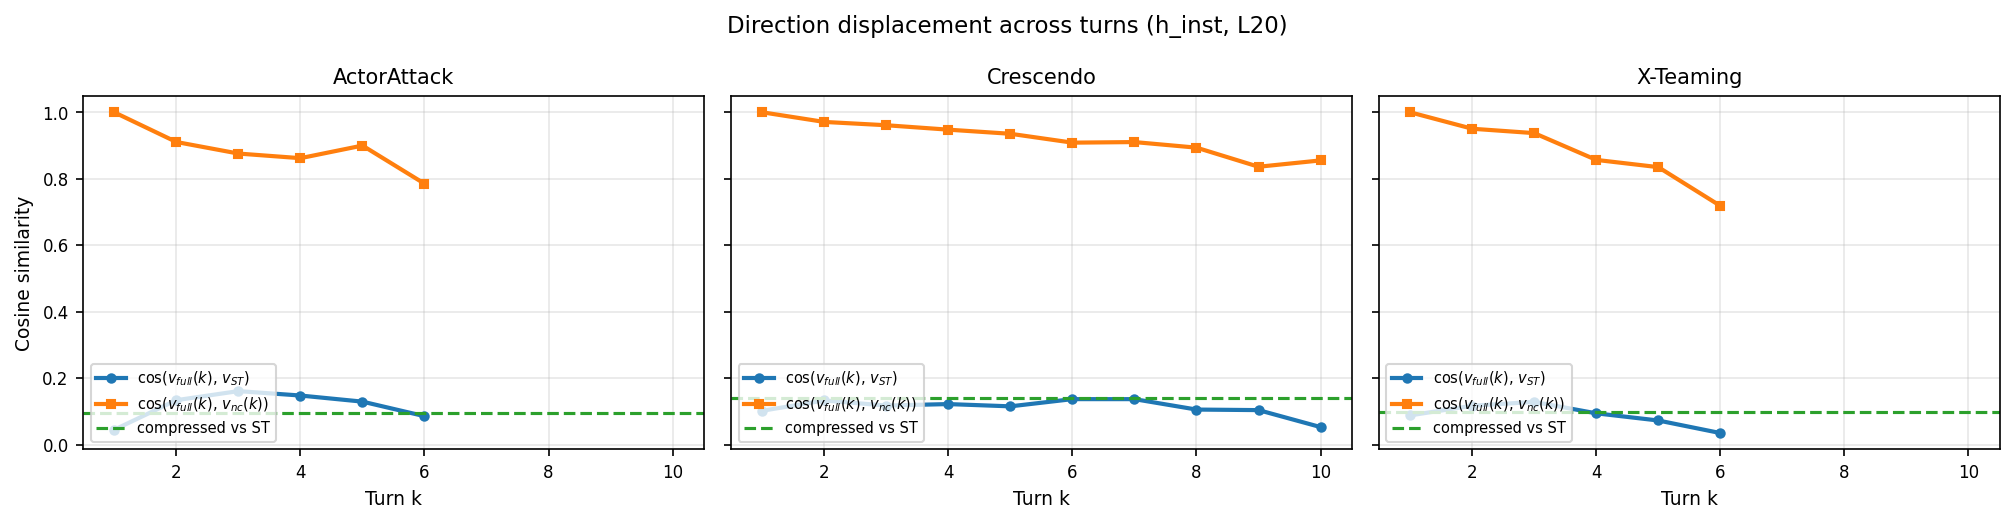

In [5]:
# ── Figure 1: Direction displacement ──────────────────────────────────────────
fig, axes = plt.subplots(1, n_fw, figsize=(4.5*n_fw, 3.5), sharey=True)
if n_fw == 1: axes = [axes]

for col, fw in enumerate(avail_fw):
    ax = axes[col]
    ks_drift, cos_drift, ks_ctx, cos_ctx = [], [], [], []

    for k in range(1, MAX_K+1):
        vf = v_full.get((fw, k))
        if vf is None: continue
        ks_drift.append(k)
        cos_drift.append(cosine(vf, v_st[L]))

        vn = v_nc_dir.get((fw, k))
        if vn is not None:
            ks_ctx.append(k)
            cos_ctx.append(cosine(vf, vn))

    ax.plot(ks_drift, cos_drift, 'o-', color='#1f77b4', lw=2, ms=4,
            label=r'cos($v_{full}(k)$, $v_{ST}$)')
    if ks_ctx:
        ax.plot(ks_ctx, cos_ctx, 's-', color='#ff7f0e', lw=2, ms=4,
                label=r'cos($v_{full}(k)$, $v_{nc}(k)$)')

    vc = v_comp_dir.get(fw)
    if vc is not None:
        ax.axhline(cosine(vc, v_st[L]), color='#2ca02c', ls='--', lw=1.5,
                   label='compressed vs ST')

    ax.set_xlabel('Turn k')
    ax.set_title(FW_LABELS[fw])
    ax.set_xlim(0.5, MAX_K+0.5)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc='lower left')

axes[0].set_ylabel('Cosine similarity')
fig.suptitle(f'Direction displacement across turns (h_inst, {FOCAL_LABEL})', fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / 'results_fig1_displacement.png')
plt.show()

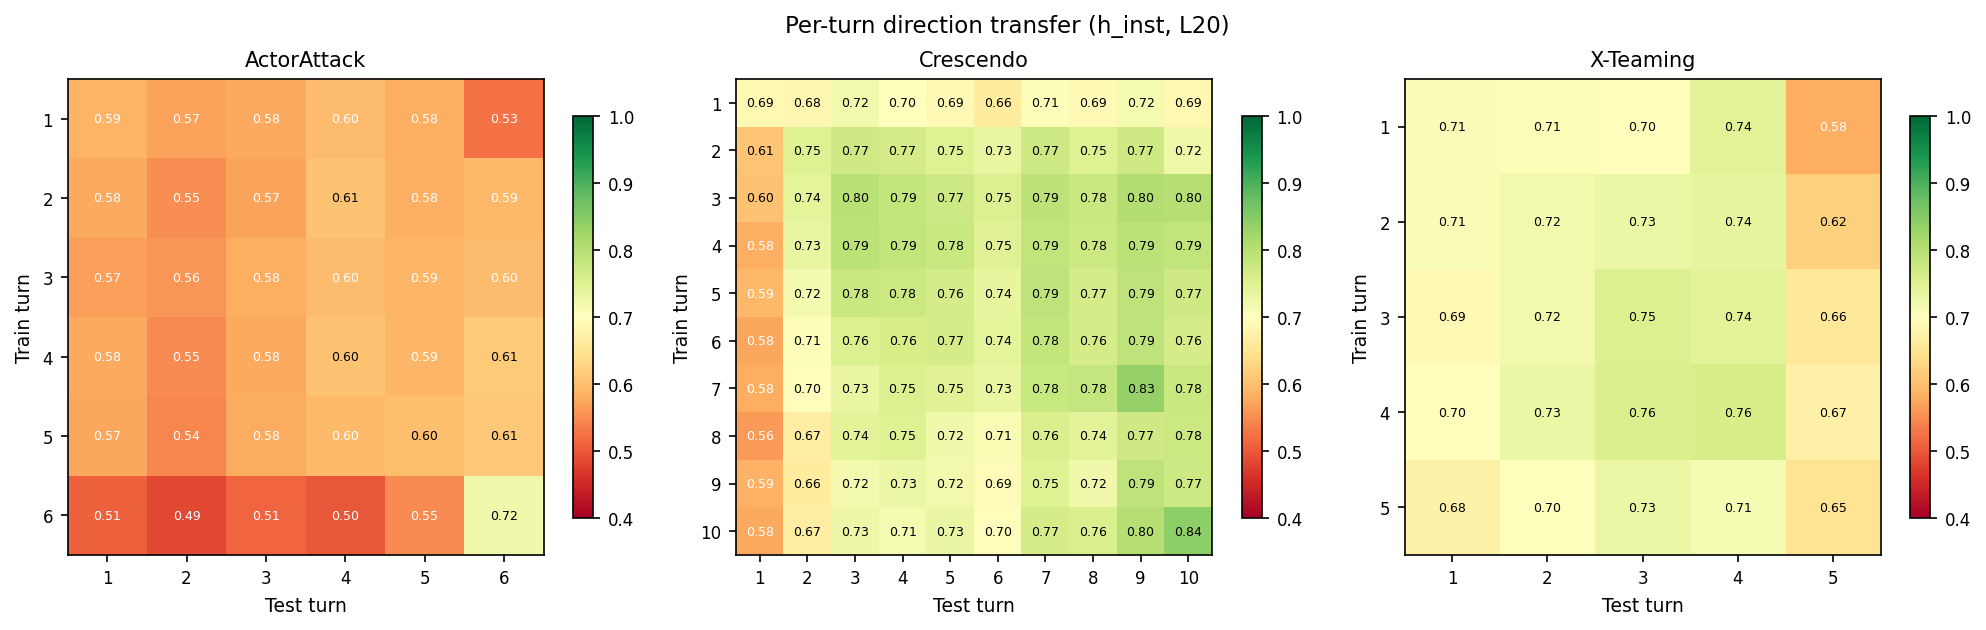

In [6]:
# ── Figure 2: Per-turn direction transfer ────────────────────────────────────
# Train direction at k_train, project test data at k_test, compute AUROC.

def auroc_dir_transfer(fw, k_train, k_test):
    v = v_full.get((fw, k_train))
    if v is None: return np.nan
    dh, db = traj.get((fw,'harmful')), traj.get((fw,'benign'))
    if dh is None or db is None: return np.nan
    teh = ((dh['meta']['turn_k']==k_test)&(dh['meta']['data_split']=='test')).values
    teb = ((db['meta']['turn_k']==k_test)&(db['meta']['data_split']=='test')).values
    if teh.sum()<5 or teb.sum()<5: return np.nan
    h = np.concatenate([dh['h_inst'][teh, L, :], db['h_inst'][teb, L, :]]).astype(np.float32)
    y = np.concatenate([np.ones(teh.sum()), np.zeros(teb.sum())])
    return roc_auc_score(y, h @ v)

fig, axes = plt.subplots(1, n_fw, figsize=(4.5*n_fw, 4), squeeze=False)

for col, fw in enumerate(avail_fw):
    ax = axes[0, col]
    valid_ks = [k for k in range(1, MAX_K+1) if v_full.get((fw,k)) is not None
                and n_at_k.get((fw,k),0) >= 5]
    nk = len(valid_ks)
    mat = np.full((nk, nk), np.nan)
    for i, kt in enumerate(valid_ks):
        for j, ke in enumerate(valid_ks):
            mat[i,j] = auroc_dir_transfer(fw, kt, ke)

    im = ax.imshow(mat, cmap='RdYlGn', vmin=0.4, vmax=1.0)
    ax.set_xticks(range(nk)); ax.set_xticklabels([f'{k}' for k in valid_ks])
    ax.set_yticks(range(nk)); ax.set_yticklabels([f'{k}' for k in valid_ks])
    ax.set_xlabel('Test turn'); ax.set_ylabel('Train turn')
    ax.set_title(FW_LABELS[fw])
    for i in range(nk):
        for j in range(nk):
            v = mat[i,j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6,
                        color='white' if v<0.6 else 'black')
    plt.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle(f'Per-turn direction transfer (h_inst, {FOCAL_LABEL})', fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / 'results_fig2_turn_transfer.png')
plt.show()

## Q2: Does this displacement cause detection methods to fail, and can more powerful classifiers recover the lost signal?

**Figure 3** compares fixed (v_ST) vs adaptive (v_full(k)) AUROC across turns.

**Figure 4** is the cross-condition transfer matrix (linear vs MLP) — the critical
test of whether the failure is structural or a capacity limitation.

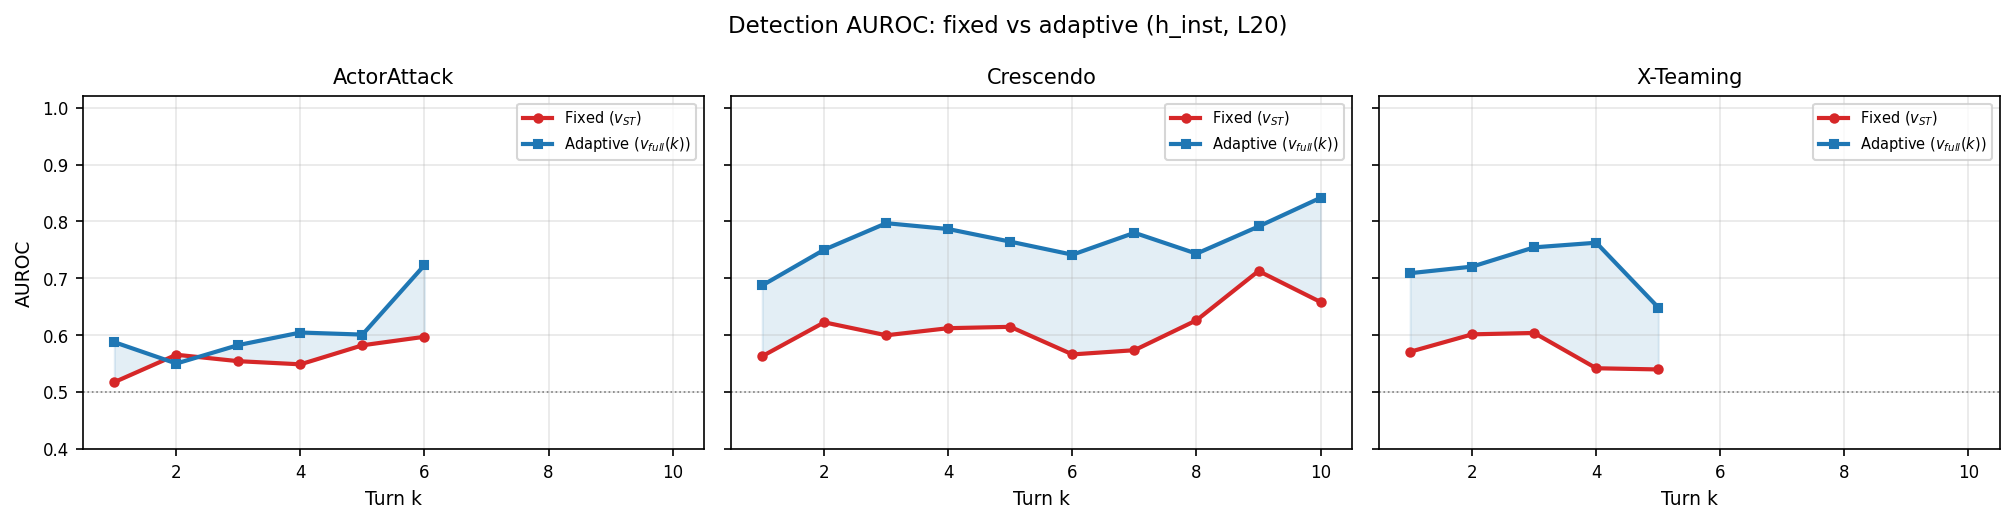

In [7]:
# ── Figure 3: Fixed vs adaptive AUROC ────────────────────────────────────────
def auroc_at_k(fw, direction, k):
    dh, db = traj.get((fw,'harmful')), traj.get((fw,'benign'))
    if dh is None or db is None: return np.nan
    teh = ((dh['meta']['turn_k']==k)&(dh['meta']['data_split']=='test')).values
    teb = ((db['meta']['turn_k']==k)&(db['meta']['data_split']=='test')).values
    if teh.sum()<5 or teb.sum()<5: return np.nan
    h = np.concatenate([dh['h_inst'][teh, L, :], db['h_inst'][teb, L, :]]).astype(np.float32)
    y = np.concatenate([np.ones(teh.sum()), np.zeros(teb.sum())])
    return roc_auc_score(y, h @ direction)

fig, axes = plt.subplots(1, n_fw, figsize=(4.5*n_fw, 3.5), sharey=True)
if n_fw == 1: axes = [axes]

for col, fw in enumerate(avail_fw):
    ax = axes[col]
    ks, fixed, adaptive = [], [], []
    for k in range(1, MAX_K+1):
        va = v_full.get((fw, k))
        if va is None: continue
        af = auroc_at_k(fw, v_st[L], k)
        aa = auroc_at_k(fw, va, k)
        if np.isnan(af) or np.isnan(aa): continue
        ks.append(k); fixed.append(af); adaptive.append(aa)

    ax.plot(ks, fixed, 'o-', color='#d62728', lw=2, ms=4, label=r'Fixed ($v_{ST}$)')
    ax.plot(ks, adaptive, 's-', color='#1f77b4', lw=2, ms=4, label=r'Adaptive ($v_{full}(k)$)')
    ax.fill_between(ks, fixed, adaptive, alpha=0.12, color='#1f77b4')
    ax.axhline(0.5, color='gray', ls=':', lw=0.8)
    ax.set_xlabel('Turn k'); ax.set_title(FW_LABELS[fw])
    ax.set_ylim(0.4, 1.02); ax.set_xlim(0.5, MAX_K+0.5)
    ax.legend(); ax.grid(True, alpha=0.3)

axes[0].set_ylabel('AUROC')
fig.suptitle(f'Detection AUROC: fixed vs adaptive (h_inst, {FOCAL_LABEL})', fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / 'results_fig3_fixed_vs_adaptive.png')
plt.show()

Transfer matrices:   0%|          | 0/3 [00:00<?, ?it/s]/Users/lisahusieva/Desktop/multi-turn-rep-eng/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/lisahusieva/Desktop/multi-turn-rep-eng/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=30

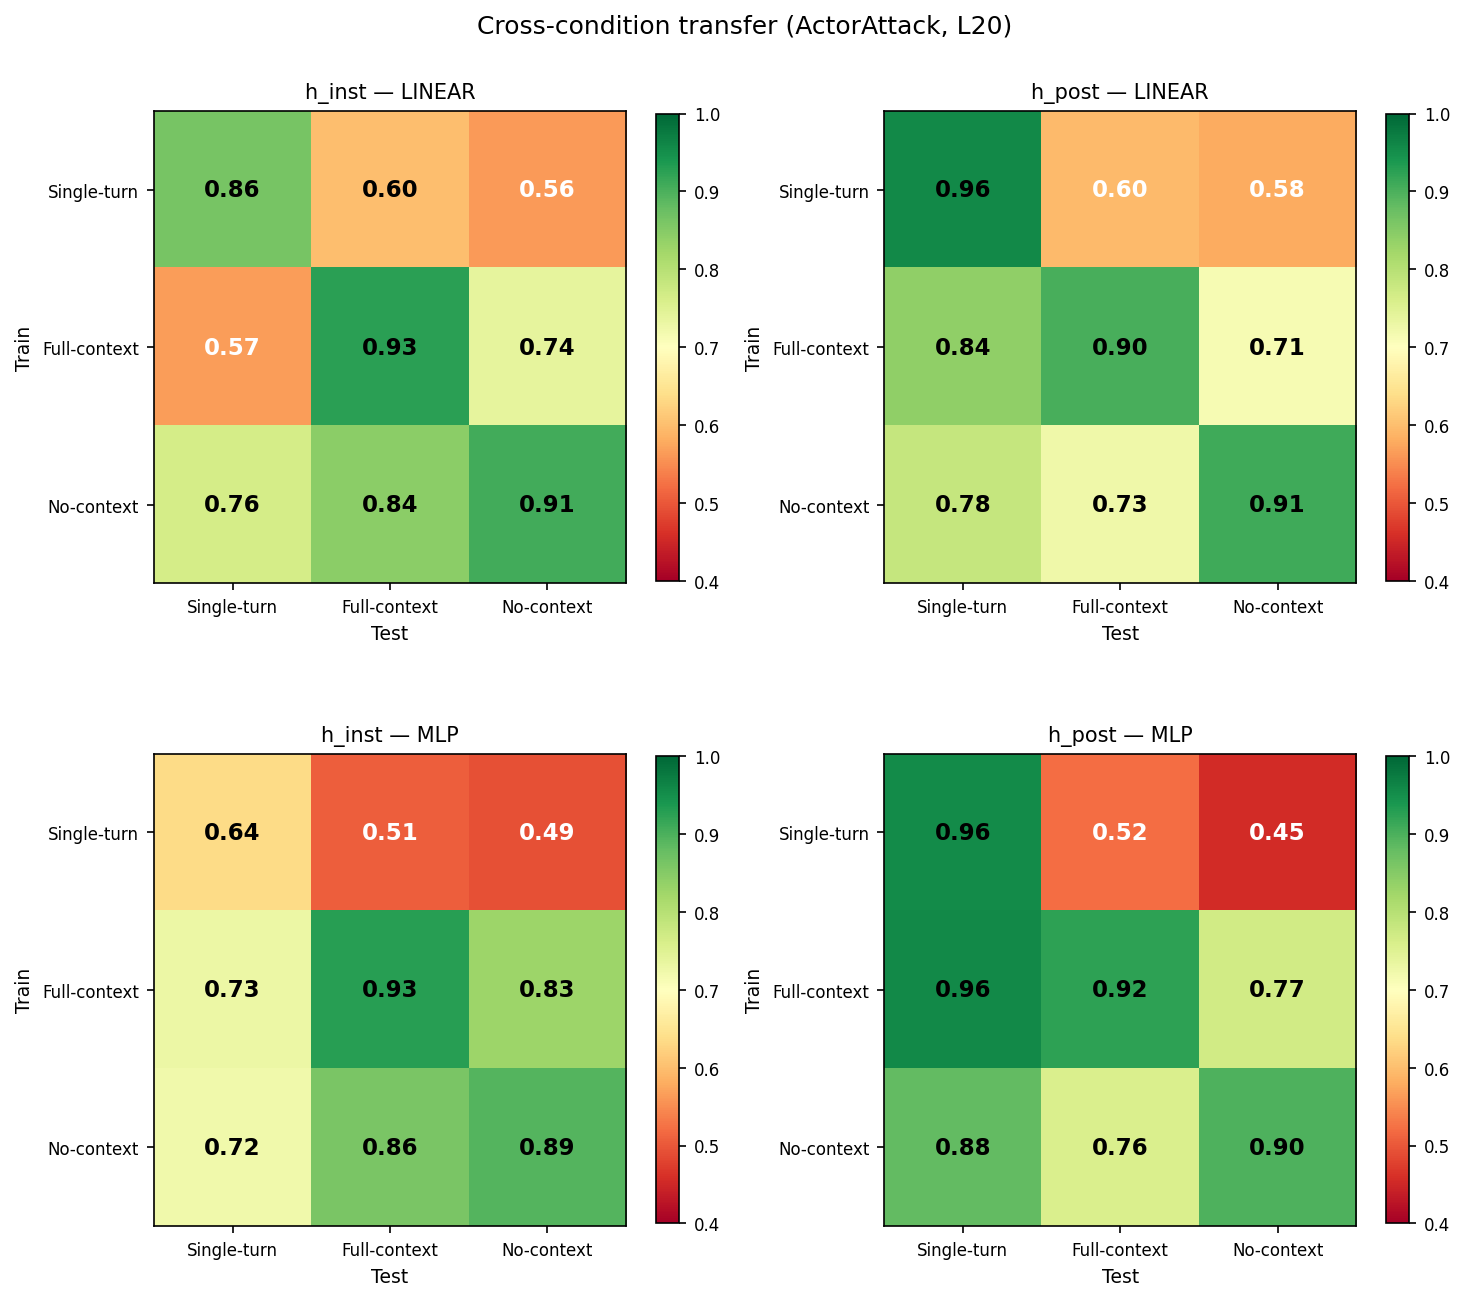

Transfer matrices:  33%|███▎      | 1/3 [00:12<00:25, 12.82s/it]

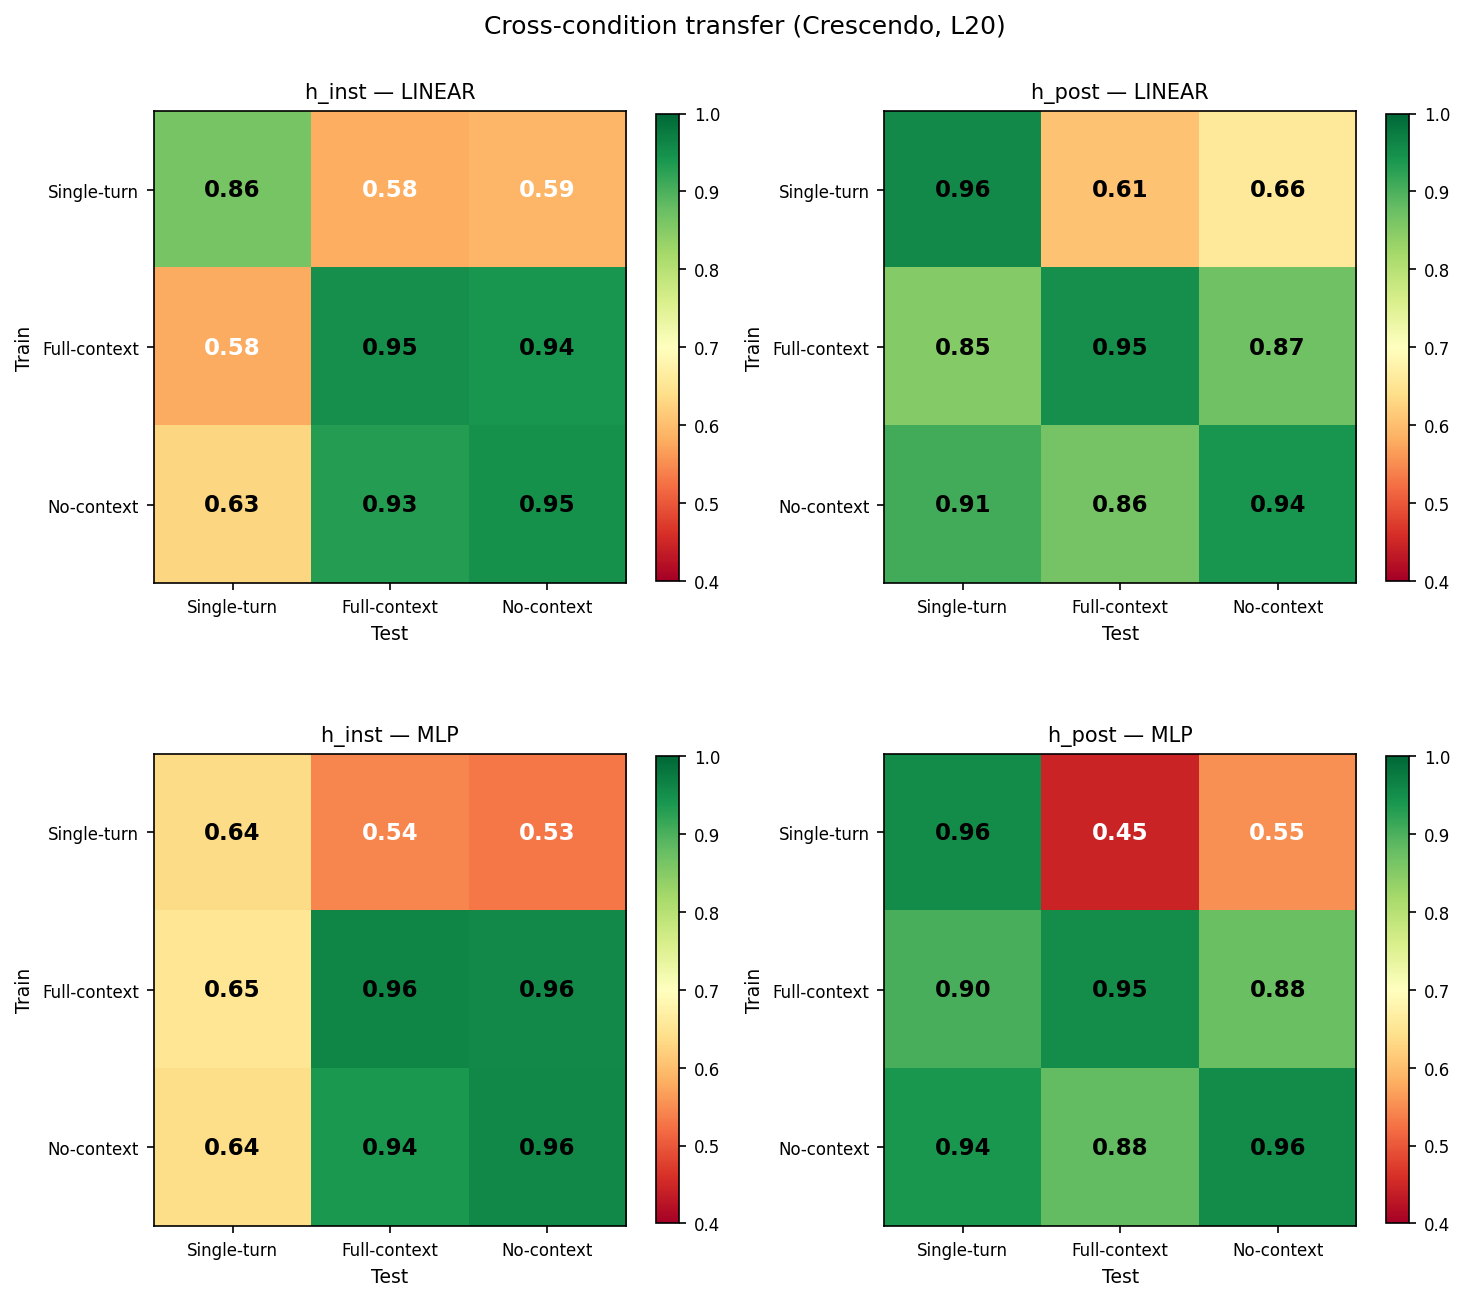

Transfer matrices:  67%|██████▋   | 2/3 [00:21<00:10, 10.27s/it]

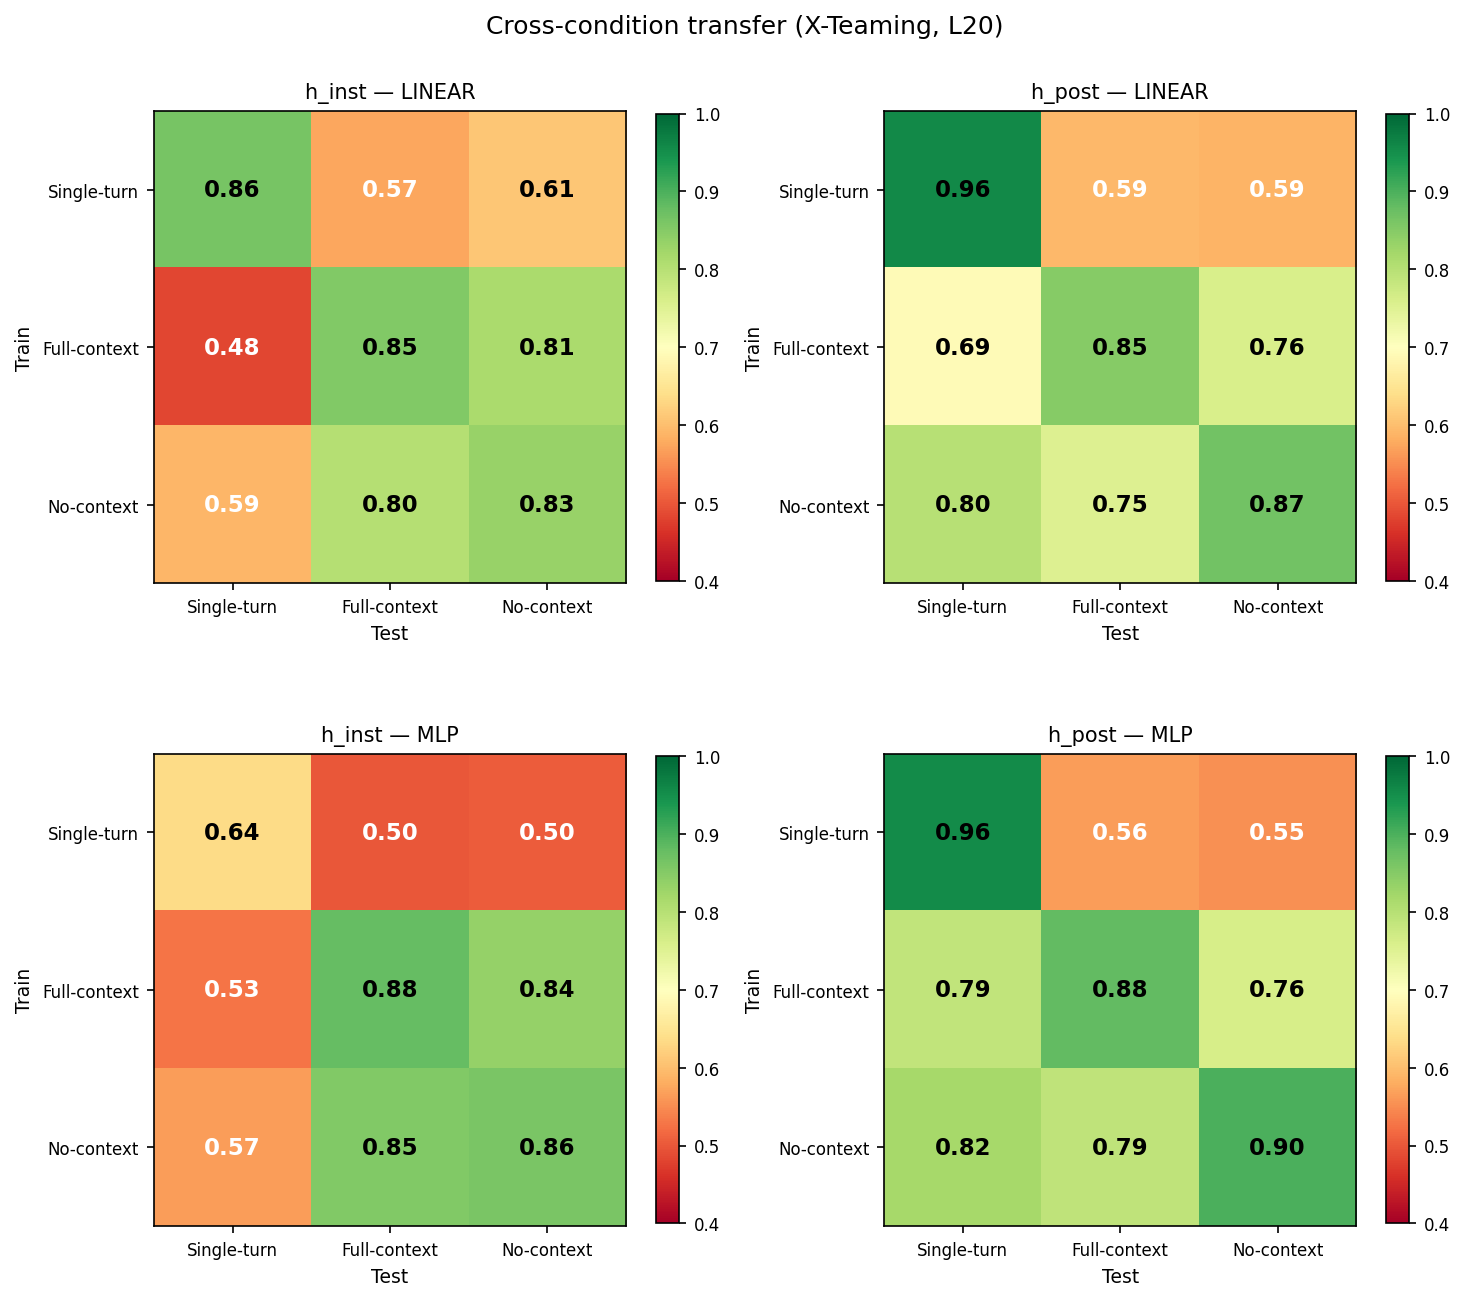

Transfer matrices: 100%|██████████| 3/3 [00:33<00:00, 11.11s/it]


In [8]:
# ── Figure 4: Cross-condition transfer matrix ─────────────────────────────────
def prepare_ds(data_dict, fw, h_key, layer, split='train', turn_k=None):
    dh, db = data_dict.get((fw,'harmful')), data_dict.get((fw,'benign'))
    if dh is None or db is None: return None, None
    mh, mb = dh['meta'], db['meta']
    if turn_k is not None:
        maskh = (mh['turn_k']==turn_k) & (mh['data_split']==split) if 'data_split' in mh.columns else (mh['turn_k']==turn_k)
        maskb = (mb['turn_k']==turn_k) & (mb['data_split']==split) if 'data_split' in mb.columns else (mb['turn_k']==turn_k)
    else:
        fth, ftb = final_turn_idx(dh), final_turn_idx(db)
        mfh, mfb = mh.loc[fth], mb.loc[ftb]
        if 'data_split' in mh.columns:
            idxh = fth[(mfh['data_split']==split).values]
            idxb = ftb[(mfb['data_split']==split).values]
        else:
            idxh, idxb = fth, ftb
        Xh = dh[h_key][idxh, layer, :].astype(np.float32)
        Xb = db[h_key][idxb, layer, :].astype(np.float32)
        if len(Xh)<5 or len(Xb)<5: return None, None
        return np.concatenate([Xh, Xb]), np.concatenate([np.ones(len(Xh)), np.zeros(len(Xb))])
    idxh = maskh.values.nonzero()[0]; idxb = maskb.values.nonzero()[0]
    if len(idxh)<5 or len(idxb)<5: return None, None
    Xh = dh[h_key][idxh, layer, :].astype(np.float32)
    Xb = db[h_key][idxb, layer, :].astype(np.float32)
    return np.concatenate([Xh, Xb]), np.concatenate([np.ones(len(Xh)), np.zeros(len(Xb))])

def train_eval(Xtr, ytr, Xte, yte, kind='linear'):
    if Xtr is None or Xte is None: return np.nan
    if len(np.unique(ytr))<2 or len(np.unique(yte))<2: return np.nan
    sc = StandardScaler(); Xtr = sc.fit_transform(Xtr); Xte = sc.transform(Xte)
    if kind=='linear':
        clf = LogisticRegression(max_iter=300, C=1.0, random_state=RNG)
    else:
        clf = MLPClassifier(hidden_layer_sizes=(64,), max_iter=300, early_stopping=True,
                            random_state=RNG, validation_fraction=0.15)
    clf.fit(Xtr, ytr)
    return roc_auc_score(yte, clf.predict_proba(Xte)[:,1])

for fw in tqdm(avail_fw, desc='Transfer matrices'):
    cond_names = ['Single-turn', 'Full-context']
    cond_data = {}

    for hk in ['h_inst', 'h_post']:
        cond_data[hk] = {}
        # ST: split 50/50
        Xa, ya = np.concatenate([st['harmful'][hk][:,L,:].astype(np.float32),
                                 st['benign'][hk][:,L,:].astype(np.float32)]), \
                 np.concatenate([np.ones(len(st['harmful']['meta'])), np.zeros(len(st['benign']['meta']))])
        nh = int(ya.sum()); nb_ = len(ya)-nh
        tri = np.concatenate([np.arange(nh//2), np.arange(nh, nh+nb_//2)])
        tei = np.concatenate([np.arange(nh//2, nh), np.arange(nh+nb_//2, nh+nb_)])
        cond_data[hk]['Single-turn'] = {'train': (Xa[tri], ya[tri]), 'test': (Xa[tei], ya[tei])}
        # FC
        Xtr, ytr = prepare_ds(traj, fw, hk, L, 'train')
        Xte, yte = prepare_ds(traj, fw, hk, L, 'test')
        cond_data[hk]['Full-context'] = {'train': (Xtr, ytr), 'test': (Xte, yte)}
        # NC
        if has_nc and (fw,'harmful') in nc:
            Xtr, ytr = prepare_ds(nc, fw, hk, L, 'train')
            Xte, yte = prepare_ds(nc, fw, hk, L, 'test')
            cond_data[hk]['No-context'] = {'train': (Xtr, ytr), 'test': (Xte, yte)}
            if 'No-context' not in cond_names: cond_names.append('No-context')

    nc_ = len(cond_names)
    fig, axes = plt.subplots(2, 2, figsize=(5*2, 4.5*2))
    for col, (hk, pl) in enumerate([('h_inst','h_inst'), ('h_post','h_post')]):
        for row, mt in enumerate(['linear', 'mlp']):
            ax = axes[row, col]
            mat = np.full((nc_, nc_), np.nan)
            for i, ctr in enumerate(cond_names):
                for j, cte in enumerate(cond_names):
                    Xtr, ytr = cond_data[hk][ctr]['train']
                    Xte, yte = cond_data[hk][cte]['test']
                    mat[i,j] = train_eval(Xtr, ytr, Xte, yte, mt)
            im = ax.imshow(mat, cmap='RdYlGn', vmin=0.4, vmax=1.0)
            ax.set_xticks(range(nc_)); ax.set_xticklabels(cond_names, fontsize=8)
            ax.set_yticks(range(nc_)); ax.set_yticklabels(cond_names, fontsize=8)
            ax.set_xlabel('Test'); ax.set_ylabel('Train')
            ax.set_title(f'{pl} \u2014 {mt.upper()}')
            for i in range(nc_):
                for j in range(nc_):
                    v = mat[i,j]
                    if not np.isnan(v):
                        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                                fontsize=11, fontweight='bold',
                                color='white' if v<0.6 else 'black')
            plt.colorbar(im, ax=ax, shrink=0.8)

    fig.suptitle(f'Cross-condition transfer ({FW_LABELS[fw]}, {FOCAL_LABEL})', fontsize=12)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'results_fig4_transfer_{fw}.png')
    plt.show()

## Q3: Do the token positions identified by Zhao et al. retain their functional roles in multi-turn settings?

**Figure 5** tests position specificity: h_inst should beat h_post on harmfulness,
h_post should beat h_inst on refusal. Two rows (full-context, no-context),
two columns (harmfulness, refusal), all frameworks overlaid, across layers.

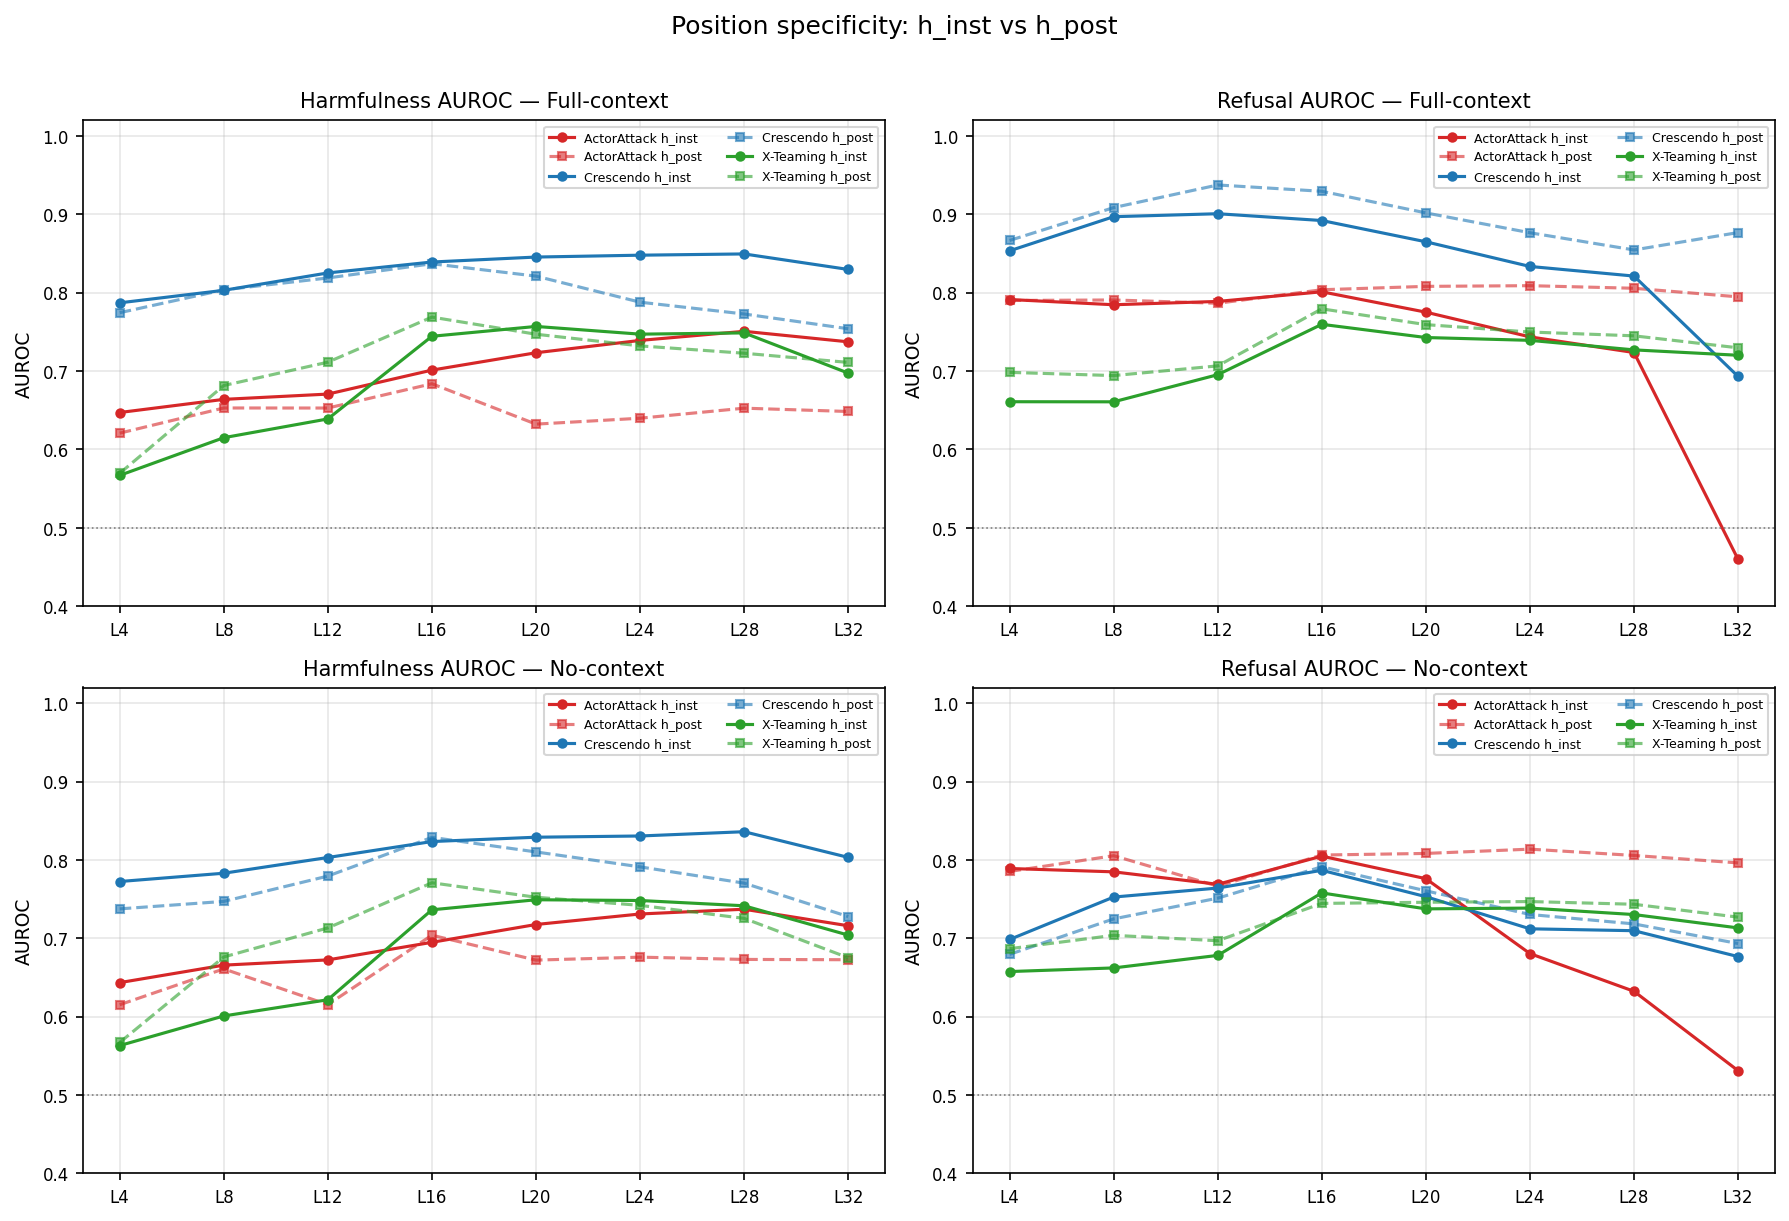

In [9]:
# ── Figure 5: Position specificity ────────────────────────────────────────────
def harm_auroc_at_layer(data_dict, fw, h_key, layer, v_dir):
    dh, db = data_dict.get((fw,'harmful')), data_dict.get((fw,'benign'))
    if dh is None or db is None or v_dir is None: return np.nan
    fth, ftb = final_turn_idx(dh), final_turn_idx(db)
    mfh = dh['meta'].loc[fth]; mfb = db['meta'].loc[ftb]
    teh = (mfh['data_split']=='test').values if 'data_split' in mfh.columns else np.ones(len(mfh), dtype=bool)
    teb = (mfb['data_split']=='test').values if 'data_split' in mfb.columns else np.ones(len(mfb), dtype=bool)
    hh = dh[h_key][fth[teh], layer, :].astype(np.float32)
    hb = db[h_key][ftb[teb], layer, :].astype(np.float32)
    if len(hh)<5 or len(hb)<5: return np.nan
    y = np.concatenate([np.ones(len(hh)), np.zeros(len(hb))])
    return roc_auc_score(y, np.concatenate([hh, hb]) @ v_dir)

def ref_auroc_at_layer(data_dict, fw, h_key, layer, v_dir):
    dh = data_dict.get((fw,'harmful'))
    if dh is None or v_dir is None: return np.nan
    fth = final_turn_idx(dh)
    mfh = dh['meta'].loc[fth]
    te = (mfh['data_split']=='test').values if 'data_split' in mfh.columns else np.ones(len(mfh), dtype=bool)
    m_te = mfh[te]
    h = dh[h_key][fth[te], layer, :].astype(np.float32)
    y = (m_te['attack_success'].values==False).astype(int)  # 1=refused
    if y.sum()<5 or (1-y).sum()<5: return np.nan
    return roc_auc_score(y, h @ v_dir)

conds = [('Full-context', traj)]
if has_nc: conds.append(('No-context', nc))

fig, axes = plt.subplots(len(conds), 2, figsize=(12, 4*len(conds)), squeeze=False)
NL = len(ALL_LAYERS)

for row, (cl, dd) in enumerate(conds):
    for fw in avail_fw:
        harm_inst, harm_post, ref_inst, ref_post = [], [], [], []
        for li in ALL_LAYERS:
            vh = v_full.get((fw, 'h_inst', li))
            vr = v_full.get((fw, 'refusal', li))
            harm_inst.append(harm_auroc_at_layer(dd, fw, 'h_inst', li, vh))
            harm_post.append(harm_auroc_at_layer(dd, fw, 'h_post', li, vh))
            ref_inst.append(ref_auroc_at_layer(dd, fw, 'h_inst', li, vr))
            ref_post.append(ref_auroc_at_layer(dd, fw, 'h_post', li, vr))

        c = FW_COLORS[fw]
        axes[row,0].plot(range(NL), harm_inst, 'o-', color=c, lw=1.5, ms=4,
                         label=f'{FW_LABELS[fw]} h_inst')
        axes[row,0].plot(range(NL), harm_post, 's--', color=c, lw=1.5, ms=4, alpha=0.6,
                         label=f'{FW_LABELS[fw]} h_post')
        axes[row,1].plot(range(NL), ref_inst, 'o-', color=c, lw=1.5, ms=4,
                         label=f'{FW_LABELS[fw]} h_inst')
        axes[row,1].plot(range(NL), ref_post, 's--', color=c, lw=1.5, ms=4, alpha=0.6,
                         label=f'{FW_LABELS[fw]} h_post')

    for ci, (ax, tl) in enumerate([(axes[row,0], f'Harmfulness AUROC \u2014 {cl}'),
                                    (axes[row,1], f'Refusal AUROC \u2014 {cl}')]):
        ax.set_xticks(range(NL)); ax.set_xticklabels(ALL_LAYER_LABELS)
        ax.set_ylabel('AUROC'); ax.set_ylim(0.4, 1.02)
        ax.axhline(0.5, color='gray', ls=':', lw=0.8)
        ax.set_title(tl); ax.legend(fontsize=6, ncol=2); ax.grid(True, alpha=0.3)

fig.suptitle('Position specificity: h_inst vs h_post', fontsize=12, y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / 'results_fig5_position_specificity.png')
plt.show()

## Q4: Where does the harmfulness signal reside — in the messages or in the conversation history?

**Figure 6** shows the nearest-centroid fraction for refused-harmful across layers:
full-context vs no-context. Fraction > 0.5 means refused-harmful clusters with
accepted-harmful (Zhao et al. prediction: ~1.0).

**Figure 7** shows behavioral correlation: projection onto v_harmful(k) split by
judge_success at each turn.

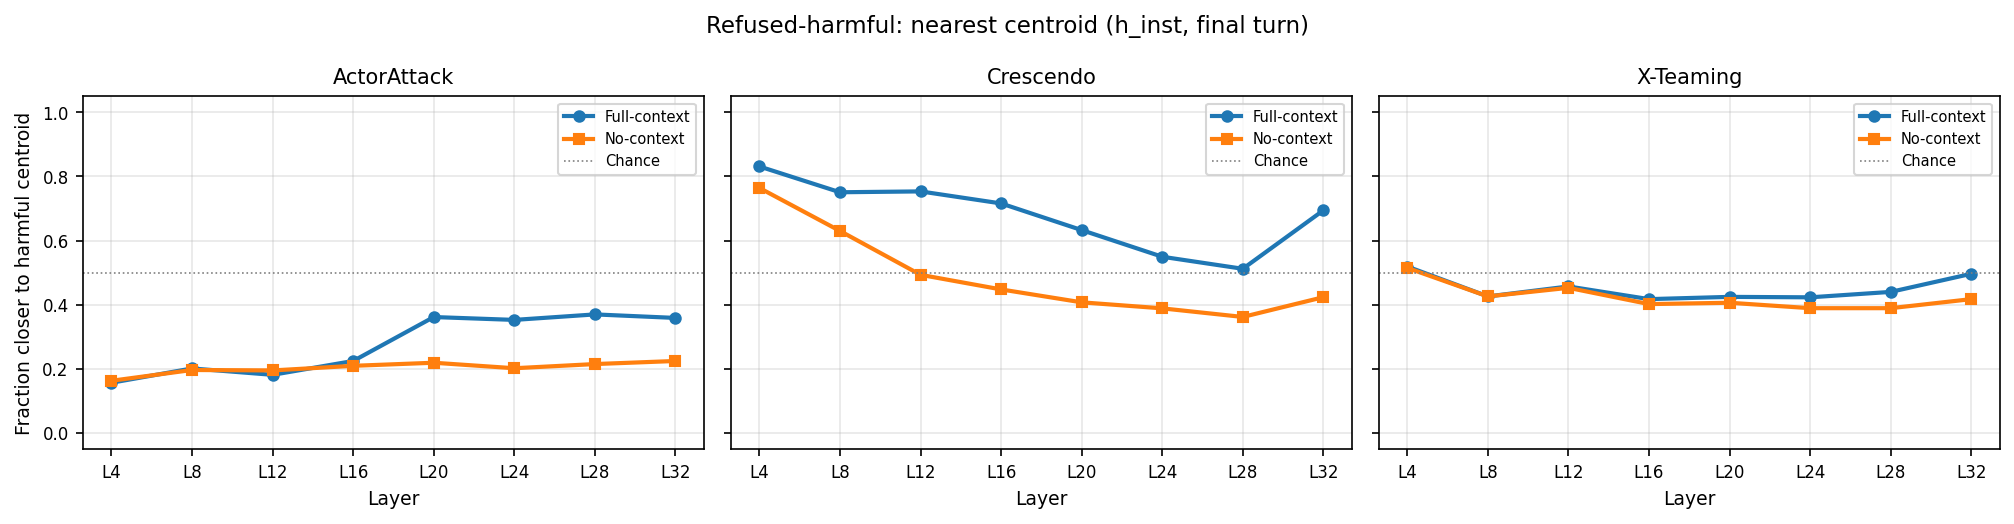

In [10]:
# ── Figure 6: Nearest-centroid fraction ───────────────────────────────────────
def nc_fraction(data_dict, fw, h_key, layer):
    dh, db = data_dict.get((fw,'harmful')), data_dict.get((fw,'benign'))
    if dh is None or db is None: return np.nan
    fth, ftb = final_turn_idx(dh), final_turn_idx(db)
    mfh = dh['meta'].loc[fth]
    acc = (mfh['attack_success'].values==True)
    ref = ~acc
    if acc.sum()<5 or ref.sum()<5: return np.nan
    h_acc = dh[h_key][fth[acc], layer, :].astype(np.float32)
    h_ref = dh[h_key][fth[ref], layer, :].astype(np.float32)
    h_ben = db[h_key][ftb, layer, :].astype(np.float32)
    c_acc = h_acc.mean(0); c_ben = h_ben.mean(0)
    return (np.linalg.norm(h_ref - c_acc, axis=1) < np.linalg.norm(h_ref - c_ben, axis=1)).mean()

fig, axes = plt.subplots(1, n_fw, figsize=(4.5*n_fw, 3.5), sharey=True)
if n_fw==1: axes = [axes]
NL = len(ALL_LAYERS)

for col, fw in enumerate(avail_fw):
    ax = axes[col]
    fc_vals = [nc_fraction(traj, fw, 'h_inst', li) for li in ALL_LAYERS]
    ax.plot(range(NL), fc_vals, 'o-', color='#1f77b4', lw=2, ms=5, label='Full-context')
    if has_nc and (fw,'harmful') in nc:
        nc_vals = [nc_fraction(nc, fw, 'h_inst', li) for li in ALL_LAYERS]
        ax.plot(range(NL), nc_vals, 's-', color='#ff7f0e', lw=2, ms=5, label='No-context')
    ax.axhline(0.5, color='gray', ls=':', lw=0.8, label='Chance')
    ax.set_xticks(range(NL)); ax.set_xticklabels(ALL_LAYER_LABELS)
    ax.set_xlabel('Layer'); ax.set_title(FW_LABELS[fw])
    ax.set_ylim(-0.05, 1.05); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Fraction closer to harmful centroid')
fig.suptitle('Refused-harmful: nearest centroid (h_inst, final turn)', fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / 'results_fig6_nearest_centroid.png')
plt.show()

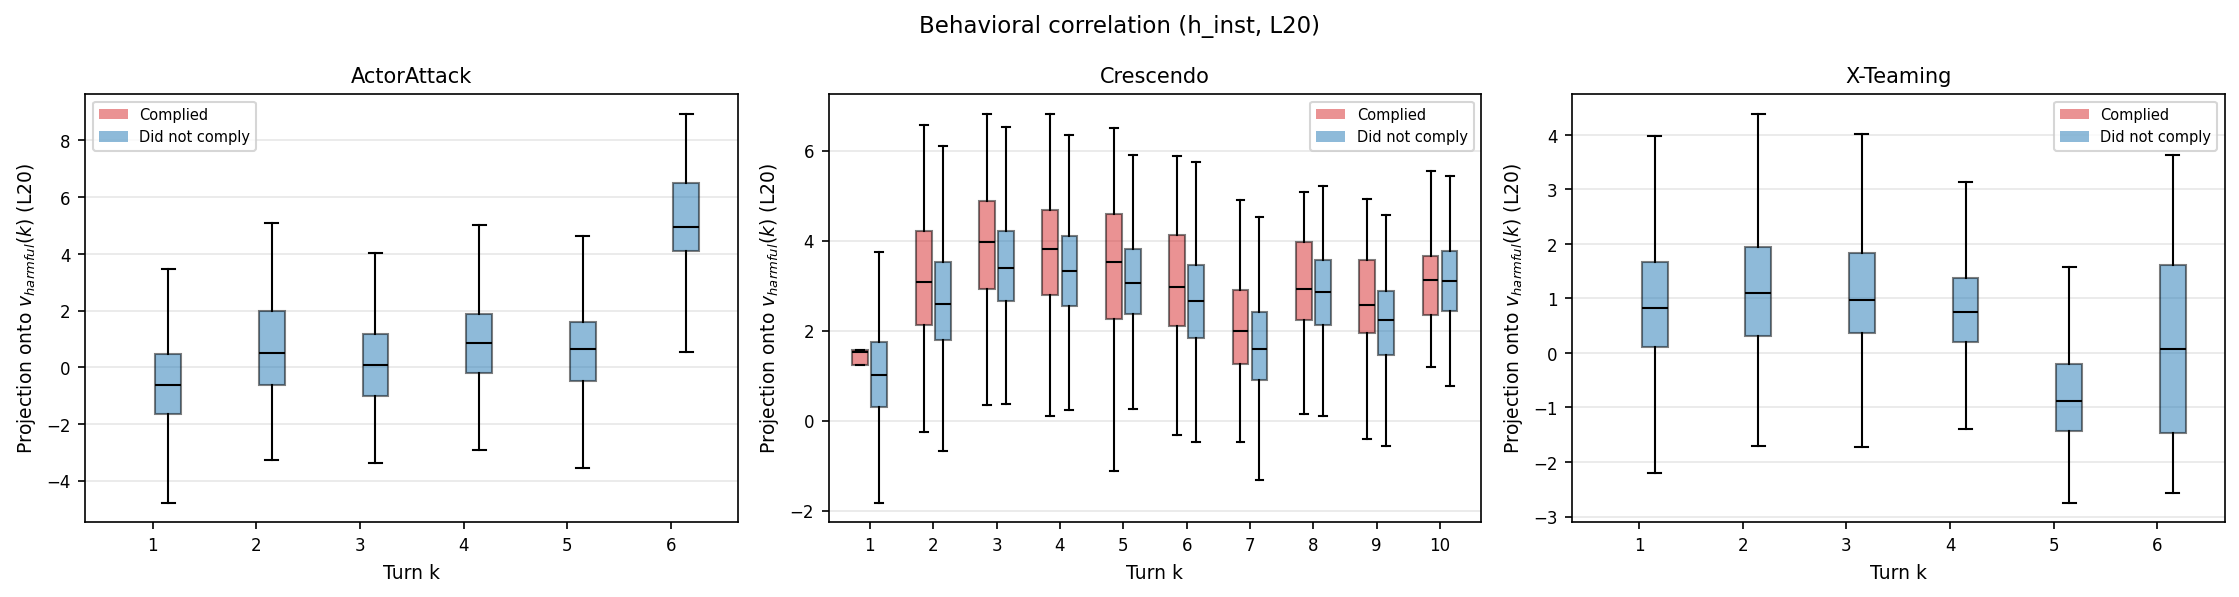

In [11]:
# ── Figure 7: Behavioral correlation ──────────────────────────────────────────
behav_fws = [fw for fw in avail_fw if fw in turn_labels and len(turn_labels[fw]) > 0]

if not behav_fws:
    print('No behavioral labels available.')
else:
    fig, axes = plt.subplots(1, len(behav_fws), figsize=(5*len(behav_fws), 4), squeeze=False)

    for col, fw in enumerate(behav_fws):
        ax = axes[0, col]
        dh = traj[(fw, 'harmful')]
        mh = dh['meta']
        m_merged = mh.merge(turn_labels[fw], on=['pair_id','attempt','turn_k'], how='left')

        proj_suc, proj_nosuc = {}, {}
        for k in range(1, MAX_K+1):
            vk = v_full.get((fw, k))
            if vk is None: continue
            mask_k = m_merged['turn_k'] == k
            hk = dh['h_inst'][mask_k.values, L, :].astype(np.float32)
            if len(hk)==0: continue
            proj = hk @ vk
            js = m_merged.loc[mask_k, 'judge_success'].values
            if js.sum()>0: proj_suc[k] = proj[js==True]
            if (~js).sum()>0: proj_nosuc[k] = proj[js==False]

        valid_ks = sorted(set(proj_suc.keys()) | set(proj_nosuc.keys()))
        bp_s = ax.boxplot([proj_suc.get(k, []) for k in valid_ks],
                          positions=[k-0.15 for k in valid_ks], widths=0.25,
                          patch_artist=True, showfliers=False,
                          boxprops=dict(facecolor='#d62728', alpha=0.5),
                          medianprops=dict(color='black'))
        bp_n = ax.boxplot([proj_nosuc.get(k, []) for k in valid_ks],
                          positions=[k+0.15 for k in valid_ks], widths=0.25,
                          patch_artist=True, showfliers=False,
                          boxprops=dict(facecolor='#1f77b4', alpha=0.5),
                          medianprops=dict(color='black'))

        ax.set_xticks(valid_ks); ax.set_xticklabels(valid_ks)
        ax.set_xlabel('Turn k')
        ax.set_ylabel(f'Projection onto $v_{{harmful}}(k)$ ({FOCAL_LABEL})')
        ax.set_title(FW_LABELS[fw])
        from matplotlib.patches import Patch
        ax.legend(handles=[Patch(facecolor='#d62728', alpha=0.5, label='Complied'),
                           Patch(facecolor='#1f77b4', alpha=0.5, label='Did not comply')],
                  fontsize=7)
        ax.grid(True, alpha=0.3, axis='y')

    fig.suptitle(f'Behavioral correlation (h_inst, {FOCAL_LABEL})', fontsize=11)
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'results_fig7_behavioral.png')
    plt.show()